# Lab: Semantic Segmentation with U-Net for Road Extraction

**Instructor:** Muhammad Sayed  
**Semester:** Spring 2026

---

### Intended Learning Outcomes (ILOs)
Upon successful completion of this lab, students will be able to:
* **Implement** a U-Net fully convolutional neural network from scratch using PyTorch to understand the mechanics of encoder-decoder architectures and skip connections.
* **Execute** a complete semantic segmentation pipeline to extract binary road networks from high-resolution, multi-modal data.
* **Design and conduct** a comparative empirical experiment evaluating the impact of distinct input modalities (optical satellite imagery vs. rendered maps vs. concatenated features) on model convergence and feature extraction.
* **Quantify** segmentation accuracy using industry-standard metrics (Jaccard Index/IoU and Dice Score) and systematically serialize experimental findings using Pydantic schemas.
* **Critically analyze** model failure modes by generating and interpreting side-by-side qualitative visual comparisons of predicted masks against ground-truth data.

> **Important Note on Performance Expectations:** > Your model's accuracy (IoU/Dice Score) should be acceptable and clearly demonstrate that learning and convergence occurred over the epochs. However, it does not need to achieve state-of-the-art or exceptionally high scores. The primary grading focus is on the correct implementation of the U-Net architecture's forward pass, the training loop mechanics, and your analytical conclusions.


In [1]:
import os
import json
import copy
from enum import Enum
from typing import List, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

from sklearn.model_selection import train_test_split

from pydantic import BaseModel
import warnings

warnings.filterwarnings('ignore')

### Experimental Setup: Input Modalities
To evaluate whether the network extracts roads more effectively using raw optical satellite imagery, rendered Google Maps data, or a combined approach, an Enum is defined to control the data loader's behavior. You will choose one of these modalities for your final experimental trial.

In [2]:
class InputModality(Enum):
    SATELLITE_ONLY = 'satellite'   # 3-channel input from the 'images' folder
    MAP_ONLY = 'map'               # 3-channel input from the 'actual' folder
    BOTH_CONCATENATED = 'both'     # 6-channel input (concatenating both images)

# You will use these Enum values when instantiating your DataLoaders for the three experiments below.


### Dataset Overview and Directory Structure
The required dataset for this lab is the **Satellite-Googlemaps-Masks** dataset, available on Kaggle:
[https://www.kaggle.com/datasets/arka47/satellitegooglemapsmasks](https://www.kaggle.com/datasets/arka47/satellitegooglemapsmasks)

The downloaded dataset contains two main folders: `train` and `val`. 
* **Test Set:** You must strictly treat the original Kaggle `val` folder as your **Test Set** to evaluate your final model.
* **Train/Validation Split:** You must dynamically split the Kaggle `train` folder into your own training and validation subsets to monitor convergence and prevent overfitting.

Inside both the `train` and `val` folders, you will find three subdirectories containing perfectly aligned 600x600 images:
1. `images/`: The raw optical satellite imagery.
2. `actual/`: The rendered Google Maps representation.
3. `label/`: The binary ground truth mask highlighting the road networks.

Depending on the `InputModality` chosen in the previous cell, your custom Dataset class must load either the satellite image (3 channels), the map image (3 channels), or stack them together (6 channels). All images and masks must be resized to **512x512 pixels** using `torchvision.transforms` to ensure dimensional compatibility with the U-Net architecture. Masks must be converted to strict binary tensors (values of 0.0 or 1.0).


In [3]:
class RoadSegmentationDataset(Dataset):
    def __init__(self, root_dir, modality: InputModality, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images (e.g., path to 'train' or 'val').
            modality (InputModality): SATELLITE_ONLY, MAP_ONLY, or BOTH_CONCATENATED.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.modality = modality
        # TODO: Dynamically load the filenames from the subdirectories
        # Hint: Use os.listdir() on the 'label' directory to get the base filenames,
        # since the filenames are identical across 'images', 'actual', and 'label'.

        self.image_transform = transform
        self.mask_transform = transforms.Compose([
            transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

        label_dir = os.path.join(self.root_dir, 'label')
        self.filenames = sorted([
            f for f in os.listdir(label_dir)
            if os.path.isfile(os.path.join(label_dir, f))
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        # TODO: Construct the full file paths based on the requested idx
        # TODO: Load the mask from the 'label/' folder
        # TODO: Load the input(s) from 'images/' and/or 'actual/' based on self.modality
        # TODO: Apply self.transform if it exists (Remember to resize to 512x512!)
        # TODO: Return a tuple of (input_tensor, mask_tensor)
        filename = self.filenames[idx]

        label_path = os.path.join(self.root_dir, 'label', filename)
        sat_path = os.path.join(self.root_dir, 'images', filename)
        map_path = os.path.join(self.root_dir, 'actual', filename)

        mask = Image.open(label_path).convert('L')
        sat_img = Image.open(sat_path).convert('RGB')
        map_img = Image.open(map_path).convert('RGB')

        if self.modality == InputModality.SATELLITE_ONLY:
            input_img = sat_img
        elif self.modality == InputModality.MAP_ONLY:
            input_img = map_img
        else:
            sat_tensor = self.image_transform(sat_img) if self.image_transform else transforms.ToTensor()(sat_img)
            map_tensor = self.image_transform(map_img) if self.image_transform else transforms.ToTensor()(map_img)
            input_tensor = torch.cat([sat_tensor, map_tensor], dim=0)

            mask_tensor = self.mask_transform(mask)
            mask_tensor = (mask_tensor > 0.5).float()
            return input_tensor, mask_tensor

        input_tensor = self.image_transform(input_img) if self.image_transform else transforms.ToTensor()(input_img)

        mask_tensor = self.mask_transform(mask)
        mask_tensor = (mask_tensor > 0.5).float()

        return input_tensor, mask_tensor

# TODO: Define your transforms (resize to 512x512, convert to Tensor, and normalize)
# TODO: Instantiate your datasets for the three experiments (e.g., train_sat, train_map, train_both, and their validation equivalents)
# TODO: Create PyTorch DataLoaders for each dataset

# Data paths
train_root = os.path.join('data', 'train')
test_root = os.path.join('data', 'val')

# Transforms (3-channel normalization is applied per image before concatenation)
image_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Full training datasets (before split)
train_sat_full = RoadSegmentationDataset(train_root, InputModality.SATELLITE_ONLY, transform=image_transform)
train_map_full = RoadSegmentationDataset(train_root, InputModality.MAP_ONLY, transform=image_transform)
train_both_full = RoadSegmentationDataset(train_root, InputModality.BOTH_CONCATENATED, transform=image_transform)

# Split train into train/validation subsets using shared indices
indices = np.arange(len(train_sat_full))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)

train_sat = Subset(train_sat_full, train_idx)
val_sat = Subset(train_sat_full, val_idx)

train_map = Subset(train_map_full, train_idx)
val_map = Subset(train_map_full, val_idx)

train_both = Subset(train_both_full, train_idx)
val_both = Subset(train_both_full, val_idx)

# Test datasets (Kaggle val set)
test_sat_dataset = RoadSegmentationDataset(test_root, InputModality.SATELLITE_ONLY, transform=image_transform)
test_map_dataset = RoadSegmentationDataset(test_root, InputModality.MAP_ONLY, transform=image_transform)
test_both_dataset = RoadSegmentationDataset(test_root, InputModality.BOTH_CONCATENATED, transform=image_transform)

# DataLoaders
batch_size = 1

train_sat_loader = DataLoader(train_sat, batch_size=batch_size, shuffle=True, num_workers=0)
val_sat_loader = DataLoader(val_sat, batch_size=batch_size, shuffle=False, num_workers=0)

train_map_loader = DataLoader(train_map, batch_size=batch_size, shuffle=True, num_workers=0)
val_map_loader = DataLoader(val_map, batch_size=batch_size, shuffle=False, num_workers=0)

train_both_loader = DataLoader(train_both, batch_size=batch_size, shuffle=True, num_workers=0)
val_both_loader = DataLoader(val_both, batch_size=batch_size, shuffle=False, num_workers=0)

test_sat_loader = DataLoader(test_sat_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_map_loader = DataLoader(test_map_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_both_loader = DataLoader(test_both_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


### U-Net Architecture implementation


The U-Net architecture consists of a **contracting path** (encoder) to capture context and a symmetric **expansive path** (decoder) that enables precise localization. 

The `__init__` function has been scaffolded for you. Notice that the first convolutional layer accepts a variable `in_channels` parameter. This is crucial for our experiment: it will be `3` if you are using only satellite or only map images, but it will be `6` if you are concatenating both modalities.

**Your Task:** Implement the `forward(self, x)` pass. You must systematically track the spatial tensors through the network and use `torch.cat` to concatenate the skip connections from the encoder to the corresponding layers in the decoder.


In [4]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Expansive Path (Decoder)
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(128, 64)

        # Final Output Layer
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # TODO: Implement the forward pass.
        # Ensure you capture intermediate outputs from self.inc, self.down1, self.down2, self.down3
        # Use torch.cat((up_sampled_tensor, skip_connection_tensor), dim=1) during the upward pass.
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5)
        x = torch.cat((x, x4), dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat((x, x3), dim=1)
        x = self.conv2(x)

        x = self.up3(x)
        x = torch.cat((x, x2), dim=1)
        x = self.conv3(x)

        x = self.up4(x)
        x = torch.cat((x, x1), dim=1)
        x = self.conv4(x)

        return self.outc(x)

### Three-Part Experimental Training
To rigorously evaluate the impact of different input features, you must train three separate U-Net models:
1. **Model A:** Trained exclusively on raw satellite imagery (3 channels).
2. **Model B:** Trained exclusively on rendered Google Maps (3 channels).
3. **Model C:** Trained on a concatenated input of both satellite and map images (6 channels).

**Important Logistical Note:** Training three distinct models can be computationally expensive. You are strongly encouraged to modularize your training loop into a reusable Python function. To ensure the lab remains manageable within reasonable compute constraints, limit your training process to a moderate number of epochs (e.g., 5 to 10 epochs per model).

Remember, the goal is to achieve acceptable, comparative convergence, not state-of-the-art absolute accuracy.


In [5]:
# TODO: Define your loss function (e.g., nn.BCEWithLogitsLoss)

# TODO: Write a reusable training function to avoid code duplication
# def train_unet(model, train_loader, val_loader, criterion, optimizer, num_epochs):
#     ...
#     return best_model

# TODO: Instantiate your three models (Sat-only, Map-only, Combined)
# Ensure the `in_channels` parameter matches the input modality for each.

# TODO: Train all three models and keep track of their best validation state.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

criterion = nn.BCEWithLogitsLoss()

def train_unet(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, device='cpu'):
    best_val_loss = float('inf')
    best_state_dict = copy.deepcopy(model.state_dict())

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                logits = model(images)
                loss = criterion(logits, masks)
                running_val_loss += loss.item() * images.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state_dict = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

    model.load_state_dict(best_state_dict)
    return model, history

num_epochs = 5

model_sat = UNet(in_channels=3, out_channels=1).to(device)
model_map = UNet(in_channels=3, out_channels=1).to(device)
model_both = UNet(in_channels=6, out_channels=1).to(device)

optimizer_sat = optim.Adam(model_sat.parameters(), lr=1e-4)
optimizer_map = optim.Adam(model_map.parameters(), lr=1e-4)
optimizer_both = optim.Adam(model_both.parameters(), lr=1e-4)

print('Training Satellite-only model...')
model_sat, history_sat = train_unet(model_sat, train_sat_loader, val_sat_loader, criterion, optimizer_sat, num_epochs=num_epochs, device=device)

print('Training Map-only model...')
model_map, history_map = train_unet(model_map, train_map_loader, val_map_loader, criterion, optimizer_map, num_epochs=num_epochs, device=device)

print('Training Combined model...')
model_both, history_both = train_unet(model_both, train_both_loader, val_both_loader, criterion, optimizer_both, num_epochs=num_epochs, device=device)

Using device: cuda
Training Satellite-only model...
Epoch [1/5] - Train Loss: 0.3938 - Val Loss: 0.2698
Epoch [2/5] - Train Loss: 0.2317 - Val Loss: 0.1968
Epoch [3/5] - Train Loss: 0.1830 - Val Loss: 0.1658
Epoch [4/5] - Train Loss: 0.1619 - Val Loss: 0.1597
Epoch [5/5] - Train Loss: 0.1479 - Val Loss: 0.1486
Training Map-only model...
Epoch [1/5] - Train Loss: 0.1785 - Val Loss: 0.1160
Epoch [2/5] - Train Loss: 0.0679 - Val Loss: 0.0624
Epoch [3/5] - Train Loss: 0.0438 - Val Loss: 0.2227
Epoch [4/5] - Train Loss: 0.0352 - Val Loss: 0.0296
Epoch [5/5] - Train Loss: 0.0307 - Val Loss: 0.0339
Training Combined model...
Epoch [1/5] - Train Loss: 0.2301 - Val Loss: 0.1245
Epoch [2/5] - Train Loss: 0.0791 - Val Loss: 0.0558
Epoch [3/5] - Train Loss: 0.0476 - Val Loss: 0.0359
Epoch [4/5] - Train Loss: 0.0375 - Val Loss: 0.1237
Epoch [5/5] - Train Loss: 0.0322 - Val Loss: 0.0601


### Qualitative Visualization


Visual context is critical for understanding network failure modes. Select exactly **3 distinct instances** from your Test set. 

For each instance, plot a 1x6 grid displaying the images side-by-side in this exact order:
`[Satellite Image] | [Map Image] | [Ground Truth Mask] | [Pred: Sat Only] | [Pred: Map Only] | [Pred: Combined]`

You must programmatically save this entire Matplotlib figure (which should be a 3x6 grid overall) to disk as `sample_predictions.png` so it can be included in your submission archive.


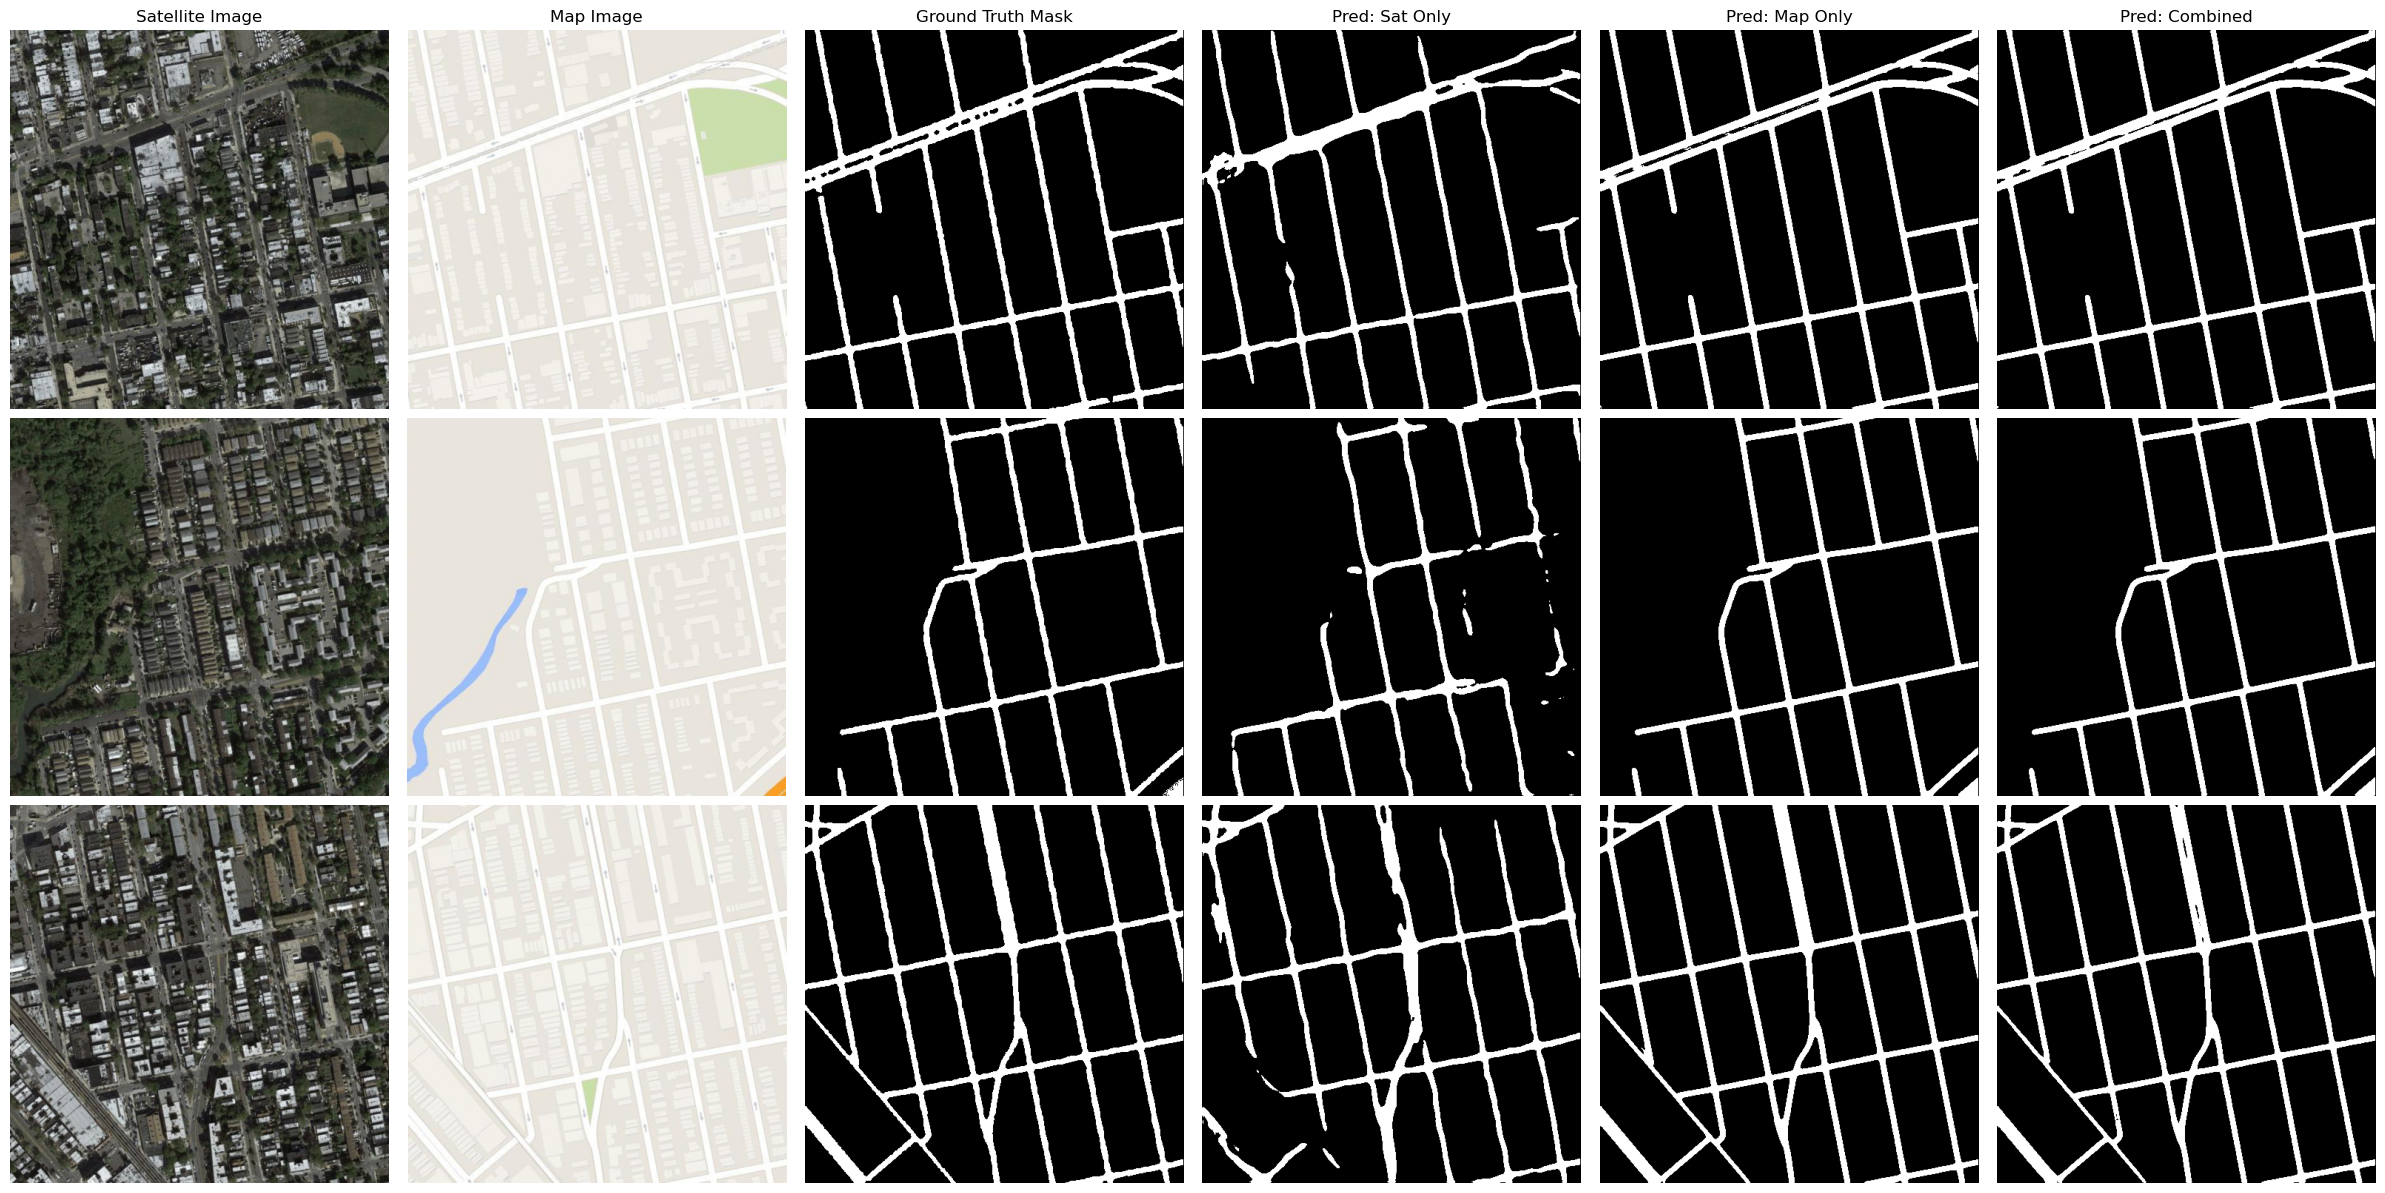

Saved qualitative figure to sample_predictions.png


In [6]:
# TODO: Fetch 3 distinct sample tuples from the Test DataLoader.
# TODO: Run the inputs through their respective trained models to generate predicted masks.
# TODO: Use matplotlib.pyplot to create the 3x6 grid.
# TODO: Save the figure using plt.savefig('sample_predictions.png', bbox_inches='tight')

def denormalize_3ch(tensor):
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    out = tensor.detach().cpu() * std + mean
    return torch.clamp(out, 0.0, 1.0)

def predict_binary_mask(model, input_tensor, device):
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor.unsqueeze(0).to(device))
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()
    return pred.squeeze().cpu().numpy()

sample_indices = [0, 1, 2]
fig, axes = plt.subplots(3, 6, figsize=(24, 12))

titles = [
    'Satellite Image',
    'Map Image',
    'Ground Truth Mask',
    'Pred: Sat Only',
    'Pred: Map Only',
    'Pred: Combined'
]

for col, title in enumerate(titles):
    axes[0, col].set_title(title)

for row, idx in enumerate(sample_indices):
    sat_input, gt_mask = test_sat_dataset[idx]
    map_input, _ = test_map_dataset[idx]
    both_input, _ = test_both_dataset[idx]

    sat_pred = predict_binary_mask(model_sat, sat_input, device)
    map_pred = predict_binary_mask(model_map, map_input, device)
    both_pred = predict_binary_mask(model_both, both_input, device)

    sat_vis = np.transpose(denormalize_3ch(sat_input).numpy(), (1, 2, 0))
    map_vis = np.transpose(denormalize_3ch(map_input).numpy(), (1, 2, 0))
    gt_vis = gt_mask.squeeze().numpy()

    axes[row, 0].imshow(sat_vis)
    axes[row, 1].imshow(map_vis)
    axes[row, 2].imshow(gt_vis, cmap='gray')
    axes[row, 3].imshow(sat_pred, cmap='gray')
    axes[row, 4].imshow(map_pred, cmap='gray')
    axes[row, 5].imshow(both_pred, cmap='gray')

    for col in range(6):
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', bbox_inches='tight')
plt.show()
print('Saved qualitative figure to sample_predictions.png')


### Quantitative Evaluation & JSON Export
Evaluate your three models on the test set utilizing the Jaccard Index (Intersection over Union - IoU) and the Dice Score. 

The `pydantic` library is utilized below to ensure the structural integrity of your final submission. Populate the models with your experimental findings and your analytical conclusion comparing the theoretical and practical value of map rendering versus raw optical imagery for road extraction.


In [11]:
class ExperimentMetrics(BaseModel):
    modality: str
    test_iou: float
    test_dice: float

class LabSubmission(BaseModel):
    student_ids: List[str]
    epochs_run_per_model: int
    metrics: List[ExperimentMetrics]
    analytical_conclusion: str

# TODO: Find or implement a function to calculate the Intersection over Union (IoU) and Dice Score based on your model's predictions.
# TODO: Populate the submission object with your actual IDs, calculated metrics, and text analysis.

def batch_iou_dice(logits, masks, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    masks = masks.view(masks.size(0), -1)

    intersection = (preds * masks).sum(dim=1)
    union = preds.sum(dim=1) + masks.sum(dim=1) - intersection

    iou = ((intersection + eps) / (union + eps)).mean().item()
    dice = ((2 * intersection + eps) / (preds.sum(dim=1) + masks.sum(dim=1) + eps)).mean().item()
    return iou, dice

def evaluate_model(model, data_loader, device):
    model.eval()

    total_iou = 0.0
    total_dice = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            batch_iou, batch_dice = batch_iou_dice(logits, masks)

            bs = images.size(0)
            total_iou += batch_iou * bs
            total_dice += batch_dice * bs
            total_samples += bs

    return total_iou / total_samples, total_dice / total_samples

sat_iou, sat_dice = evaluate_model(model_sat, test_sat_loader, device)
map_iou, map_dice = evaluate_model(model_map, test_map_loader, device)
both_iou, both_dice = evaluate_model(model_both, test_both_loader, device)

results = {
    'Satellite Only': {'iou': sat_iou, 'dice': sat_dice},
    'Map Only': {'iou': map_iou, 'dice': map_dice},
    'Combined': {'iou': both_iou, 'dice': both_dice}
}

best_modality = max(results, key=lambda m: results[m]['iou'])
print(f"Best modality: {best_modality}")

Best modality: Combined


In [15]:
analysis_text = (
    f"The experimental results demonstrate a significant performance gap between the three input modalities. The Satellite-only model achieved relatively low IoU and Dice scores, indicating difficulty in extracting road features from raw imagery due to noise, shadows, and complex visual patterns. In contrast, the Map-only model achieved substantially higher performance, as the rendered maps provide a simplified and high-contrast representation where roads are explicitly defined. This makes feature extraction significantly easier for the network. The Combined model showed only marginal improvement over the Map-only model, suggesting that the satellite imagery adds little additional useful information beyond what is already present in the map representation. In some cases, the additional modality may even introduce noise. Overall, the results indicate that structured and abstracted representations (maps) are more effective for semantic segmentation tasks than raw visual data, and that combining modalities is only beneficial when each modality contributes complementary information."
)

submission = LabSubmission(
    student_ids=["9220154", "9220393"],  # Update with your actual student IDs
    epochs_run_per_model=num_epochs,  # Update with your actual epoch count
    metrics=[
        ExperimentMetrics(
            modality="Satellite Only",
            test_iou=float(sat_iou),
            test_dice=float(sat_dice),
        ),
        ExperimentMetrics(
            modality="Map Only", test_iou=float(map_iou), test_dice=float(map_dice)
        ),
        ExperimentMetrics(
            modality="Combined", test_iou=float(both_iou), test_dice=float(both_dice)
        ),
    ],
    analytical_conclusion=analysis_text,
)

# Serialize to JSON and save
output_json = submission.model_dump_json(indent=4)
with open("student_submission.json", "w") as f:
    f.write(output_json)

print("Successfully exported student_submission.json")

Successfully exported student_submission.json


### Submission Protocol

The final deliverable **must be a zipped archive** submitted on the classroom. 

* The archive must contain:
    1. The executed Jupyter Notebook.
    2. The generated `student_submission.json` file.
    3. The saved `sample_predictions.png` image.
* The zipped file must be explicitly named utilizing the display name of the submitter exactly as it appears on Google Classroom.

---

### Grading Rubric (Total: 10 Marks)

* **Data Engineering (2 Marks):** Correctly implements the multi-modal `Dataset` class, accurately pairs the inputs, and applies the necessary 512x512 transformations and tensor conversions.
* **Architecture Implementation (3 Marks):** Successfully completes the U-Net `forward` pass with proper spatial tracking, skip connections, and adaptable input channels.
* **Training Execution (2 Marks):** Implements a functional, reusable training loop that successfully trains the three experimental models and tracks loss.
* **Evaluation & JSON Export (2 Marks):** Correctly computes Test set IoU/Dice metrics and successfully serializes the experiment and written analysis into the strictly formatted JSON payload.
* **Qualitative Output (1 Mark):** Successfully generates, formats, and saves the 3-sample comparative plot (`sample_predictions.png`).
